In [1]:
import numpy as np
import scanpy as sc
import pandas as pd
import scipy.sparse as sp
import scvi
import os
import glob
import anndata as ad
import sys 
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from pathlib import Path
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / 'src').exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))
from model.lr_dec import *

In [2]:
data_dir      = "data/GP1/processed"
model_dir     = "outputs/GP1/ckpt/scvi/scanvi"
base_dir      = "outputs/GP1/results/rollout_h5ad_gp1"
save_dir      = "outputs/GP1/results/ds_ana/counts_MLP"
ckpt_path_dec = "outputs/GP1/ckpt/exp_decoder_full/decoder_counts_normal_cancer.pt"
stat_json     = "outputs/GP1/ckpt/exp_decoder_full/decoder_counts_normal_cancer.json"
OUT_DIR       = "outputs/GP1/ckpt/exp_decoder_full"
SAMPLE_IDS    = ["normal", "cancer"]

In [3]:
adata_ori = sc.read_h5ad(f'{data_dir}/GP1.h5ad')
adata_ori.obs_names_make_unique()
adata_ori

AnnData object with n_obs × n_vars = 391 × 36601
    obs: 'in_tissue', 'array_row', 'array_col', 'cluster', '_scvi_batch', '_scvi_labels', 'state', 'tissue_side', 'status', 'source', 'cx_aligned', 'cy_aligned'
    var: 'gene_ids', 'feature_types', 'genome'
    obsm: 'X_pca', 'X_scanVI', 'X_umap', 'spatial'
    varm: 'PCs'
    layers: 'counts'

In [4]:
model = scvi.model.SCANVI.load(model_dir)
model

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


INFO     File /home/zhouyj/project/src/GP1_ckpt/scvi/scanvi/model.pt already downloaded                            


ScanVI Model with the following params: 
unlabeled_category: Unknown, n_hidden: 128, n_latent: 10, n_layers: 1, dropout_rate: 0.1, dispersion: gene, 
gene_likelihood: zinb
Training status: Trained
Model's adata is minified?: False

# Decoder for full genes

In [5]:
# genes_all = list(map(str, adata_ori.var_names))
# len(genes_all)
# results = train_count_decoder_pairs(
#     adata=adata_ori, model=model, genes=genes_all, sample_ids=SAMPLE_IDS,
#     sample_key="status", out_dir=OUT_DIR, sample_prefix="decoder_counts", layer_counts="counts",
#     skip_if_exists=False, seed=2025, test_size=0.2, batch_size=512, epochs=500, patience=10, 
#     lr=1e-3, device="cuda:0",
# )
# for r in results:
#     print(r)

In [6]:
files = sorted(glob.glob(os.path.join(base_dir, "*.h5ad")))
adatas = {}
for path in files:
    filename = os.path.basename(path)
    sample_id = os.path.splitext(filename)[0]  
    sample_adata = sc.read_h5ad(path)
    sample_adata.var_names_make_unique()
    adatas[sample_id] = sample_adata

adata_roll = ad.concat(adatas, label="sample")
adata_roll.obs_names_make_unique()

print(adata_roll.obs["sample"].value_counts())
adata_roll


sample
normal_to_cancer_f0100_t1p0000    246
normal_to_cancer_f0099_t0p9900    245
normal_to_cancer_f0098_t0p9800    244
normal_to_cancer_f0097_t0p9700    243
normal_to_cancer_f0096_t0p9600    242
                                 ... 
normal_to_cancer_f0004_t0p0400    149
normal_to_cancer_f0003_t0p0300    148
normal_to_cancer_f0002_t0p0200    147
normal_to_cancer_f0001_t0p0100    146
normal_to_cancer_f0000_t0p0000    145
Name: count, Length: 101, dtype: int64


/home/zhouyj/.conda/envs/3dslice/lib/python3.12/site-packages/anndata/_core/anndata.py:1791: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


AnnData object with n_obs × n_vars = 19728 × 0
    obs: 'cx', 'cy', 'layer_idx', 'layer_name', 'uid', 'parent_uid', 'is_birth', 'is_diff', 'diff_alpha', 'diff_tgt_layer', 'diff_tgt_layer_name', 'sample'
    obsm: 'X_latent', 'spatial'

In [8]:
device = "cuda:0" if torch.cuda.is_available() else "cpu"
sample_key = "sample"
latent_obsm_key = "X_latent"
batch = 4096

os.makedirs(save_dir, exist_ok=True)

# -----------------------
# Load decoder cfg + build decoder
# -----------------------
with open(stat_json, "r") as f:
    cfg = json.load(f)

genes_all = list(map(str, adata_ori.var_names))
if len(genes_all) == 0:
    raise ValueError("adata_ori.var_names is empty")

# training decoder output
if "genes" in cfg and len(cfg["genes"]) > 0:
    genes_model = [str(g) for g in cfg["genes"]]
else:
    genes_model = genes_all

if len(genes_model) != len(genes_all):
    raise ValueError(
        f"genemismatch:train={len(genes_model)} vs adata_ori={len(genes_all)}"
    )

if set(genes_model) != set(genes_all):
    miss1 = pd.Index(genes_model).difference(pd.Index(genes_all)).tolist()[:10]
    miss2 = pd.Index(genes_all).difference(pd.Index(genes_model)).tolist()[:10]
    raise ValueError(
        f"traininggene adata_ori genemismatch\n"
        f"train-only: {miss1}\n"
        f"adata-only: {miss2}"
    )

in_dim   = int(cfg.get("in_dim", 10))
out_dim  = int(cfg.get("out_dim", len(genes_model)))
h        = tuple(cfg.get("h", (256, 256)))
dropout  = float(cfg.get("dropout", 0.2))
noise_in = float(cfg.get("noise_in", 0.0))
noise_h  = float(cfg.get("noise_h", 0.0))

if out_dim != len(genes_model):
    raise ValueError(
        f"out_dim mismatch: json out_dim={out_dim} vs len(genes_model)={len(genes_model)}"
    )

model_dec = NoisyCountDecoder(
    in_dim=in_dim,
    out_dim=out_dim,
    h=h,
    dropout=dropout,
    noise_in=noise_in,
    noise_h=noise_h,
).to(device)

sd = torch.load(ckpt_path_dec, map_location=device)
model_dec.load_state_dict(sd, strict=True)
model_dec.eval()

# -----------------------
# helpers
# -----------------------
def _get_coords(sub: ad.AnnData) -> np.ndarray:
    if "spatial" in sub.obsm:
        c = sub.obsm["spatial"]
        return c if isinstance(c, np.ndarray) else np.asarray(c)
    if {"cx", "cy"}.issubset(sub.obs.columns):
        return sub.obs[["cx", "cy"]].to_numpy(np.float32)
    raise KeyError("coordinates:requires sub.obsm['spatial']  sub.obs[['cx','cy']]")

def _get_uid_safe(sub: ad.AnnData, N: int) -> np.ndarray:
    if "uid" in sub.obs.columns:
        u = sub.obs["uid"].astype(str).to_numpy()
    else:
        u = pd.Index(sub.obs_names).astype(str).to_numpy()
    u = np.asarray(u).reshape(-1)
    if u.shape[0] != N:
        u = pd.Index(sub.obs_names).astype(str).to_numpy()
        u = np.asarray(u).reshape(-1)
        if u.shape[0] != N:
            raise ValueError(f"uid length mismatch:len(uid)={u.shape[0]} vs N={N}")
    return u

# -----------------------
# iterate samples
# -----------------------
if sample_key not in adata_roll.obs.columns:
    raise KeyError(f"adata.obs missing '{sample_key}'")

svals = adata_roll.obs[sample_key].astype(str).values
uniq = sorted(set(svals), key=lambda x: int(x) if str(x).isdigit() else str(x))

out_paths = []

for sid in uniq:
    mask = (adata_roll.obs[sample_key].astype(str).values == str(sid))
    sub = adata_roll[mask].copy()

    if latent_obsm_key not in sub.obsm:
        raise KeyError(f"sub.obsm missing '{latent_obsm_key}'")

    Z = np.asarray(sub.obsm[latent_obsm_key], dtype=np.float32)
    Zt = torch.as_tensor(Z, device=device, dtype=torch.float32)
    cxy = _get_coords(sub).astype(np.float32)

    N = int(Zt.shape[0])
    if cxy.shape[0] != N:
        raise ValueError(f"coords count mismatch: {cxy.shape[0]} vs {N}")
    if Zt.shape[1] != in_dim:
        raise ValueError(f"latent dim mismatch: Z dim={Zt.shape[1]} vs decoder in_dim={in_dim}")

    # ===== decode in chunks: full-gene counts =====
    pred_chunks = []
    with torch.no_grad():
        for i in range(0, N, batch):
            zchunk = Zt[i:i + batch]
            pred = model_dec(zchunk)   # (B, G_all)
            pred_chunks.append(torch.clamp(pred, min=0.0).cpu().numpy())

    X_pred = np.vstack(pred_chunks).astype(np.float32)

    # ===== obs meta =====
    obs_meta = sub.obs.copy()
    obs_meta["uid"] = _get_uid_safe(sub, N)
    obs_meta.index.name = None
    obs_meta["frame"] = int(sid) if str(sid).isdigit() else str(sid)
    obs_meta["x_roll"] = cxy[:, 0].astype(np.float32)
    obs_meta["y_roll"] = cxy[:, 1].astype(np.float32)

    # ===== build AnnData =====
    adt = ad.AnnData(
        X=X_pred,
        obs=obs_meta,
        var=pd.DataFrame(index=pd.Index(genes_model, name=None)),
        dtype=np.float32,
    )

    adt.layers["counts_hat"] = X_pred.astype(np.float32, copy=False)
    adt.obsm["spatial"] = cxy
    adt.obsm[latent_obsm_key] = np.asarray(sub.obsm[latent_obsm_key], dtype=np.float32)

    adt.uns["sample"] = str(sid)
    adt.obs.index.name = None

    out_path = os.path.join(
        save_dir,
        f"counts_pred_sample{int(sid):02d}.h5ad" if str(sid).isdigit() else f"counts_pred_sample_{sid}.h5ad"
    )
    adt.write(out_path)
    out_paths.append(out_path)

print(f">> Saved {len(out_paths)} files to: {save_dir}")
print(out_paths[:3], "..." if len(out_paths) > 3 else "")

/home/zhouyj/.conda/envs/3dslice/lib/python3.12/site-packages/legacy_api_wrap/__init__.py:82: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  return fn(*args_all, **kw)
/home/zhouyj/.conda/envs/3dslice/lib/python3.12/site-packages/legacy_api_wrap/__init__.py:82: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  return fn(*args_all, **kw)
/home/zhouyj/.conda/envs/3dslice/lib/python3.12/site-packages/legacy_api_wrap/__init__.py:82: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  return fn(*args_all, **kw)
/home/zhouyj/.conda/envs/3dslice/lib/python3.12/site-packages/legacy_api_wrap/__init__.py:82: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  return fn(*args_all, **kw)
/home/zhouyj/.conda/envs/3dslice/lib/python3.12/site-packages/legacy_api_wrap/__init__.py:82: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  re

>> Saved 101 files to: /home/zhouyj/project/src/GP1_results/ds_ana/counts_MLP
['/home/zhouyj/project/src/GP1_results/ds_ana/counts_MLP/counts_pred_sample_normal_to_cancer_f0000_t0p0000.h5ad', '/home/zhouyj/project/src/GP1_results/ds_ana/counts_MLP/counts_pred_sample_normal_to_cancer_f0001_t0p0100.h5ad', '/home/zhouyj/project/src/GP1_results/ds_ana/counts_MLP/counts_pred_sample_normal_to_cancer_f0002_t0p0200.h5ad'] ...


/home/zhouyj/.conda/envs/3dslice/lib/python3.12/site-packages/legacy_api_wrap/__init__.py:82: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  return fn(*args_all, **kw)


In [9]:
adata_ori

AnnData object with n_obs × n_vars = 391 × 36601
    obs: 'in_tissue', 'array_row', 'array_col', 'cluster', '_scvi_batch', '_scvi_labels', 'state', 'tissue_side', 'status', 'source', 'cx_aligned', 'cy_aligned'
    var: 'gene_ids', 'feature_types', 'genome'
    obsm: 'X_pca', 'X_scanVI', 'X_umap', 'spatial'
    varm: 'PCs'
    layers: 'counts'

In [10]:
device = "cuda:0" if torch.cuda.is_available() else "cpu"
sample_key = "status"
latent_obsm_key = "X_scanVI"
batch = 4096

os.makedirs(save_dir, exist_ok=True)

# -----------------------
# Load decoder cfg + build decoder
# -----------------------
with open(stat_json, "r") as f:
    cfg = json.load(f)

genes_all = list(map(str, adata_ori.var_names))
if len(genes_all) == 0:
    raise ValueError("adata_ori.var_names is empty")

# training decoder output
if "genes" in cfg and len(cfg["genes"]) > 0:
    genes_model = [str(g) for g in cfg["genes"]]
else:
    genes_model = genes_all

if len(genes_model) != len(genes_all):
    raise ValueError(
        f"genemismatch:train={len(genes_model)} vs adata_ori={len(genes_all)}"
    )

if set(genes_model) != set(genes_all):
    miss1 = pd.Index(genes_model).difference(pd.Index(genes_all)).tolist()[:10]
    miss2 = pd.Index(genes_all).difference(pd.Index(genes_model)).tolist()[:10]
    raise ValueError(
        f"traininggene adata_ori genemismatch\n"
        f"train-only: {miss1}\n"
        f"adata-only: {miss2}"
    )

in_dim   = int(cfg.get("in_dim", 10))
out_dim  = int(cfg.get("out_dim", len(genes_model)))
h        = tuple(cfg.get("h", (256, 256)))
dropout  = float(cfg.get("dropout", 0.2))
noise_in = float(cfg.get("noise_in", 0.0))
noise_h  = float(cfg.get("noise_h", 0.0))

if out_dim != len(genes_model):
    raise ValueError(
        f"out_dim mismatch: json out_dim={out_dim} vs len(genes_model)={len(genes_model)}"
    )

model_dec = NoisyCountDecoder(
    in_dim=in_dim,
    out_dim=out_dim,
    h=h,
    dropout=dropout,
    noise_in=noise_in,
    noise_h=noise_h,
).to(device)

sd = torch.load(ckpt_path_dec, map_location=device)
model_dec.load_state_dict(sd, strict=True)
model_dec.eval()

# -----------------------
# helpers
# -----------------------
def _get_coords(sub: ad.AnnData) -> np.ndarray:
    if "spatial" in sub.obsm:
        c = sub.obsm["spatial"]
        return c if isinstance(c, np.ndarray) else np.asarray(c)
    if {"cx", "cy"}.issubset(sub.obs.columns):
        return sub.obs[["cx", "cy"]].to_numpy(np.float32)
    raise KeyError("coordinates:requires sub.obsm['spatial']  sub.obs[['cx','cy']]")

def _get_uid_safe(sub: ad.AnnData, N: int) -> np.ndarray:
    if "uid" in sub.obs.columns:
        u = sub.obs["uid"].astype(str).to_numpy()
    else:
        u = pd.Index(sub.obs_names).astype(str).to_numpy()
    u = np.asarray(u).reshape(-1)
    if u.shape[0] != N:
        u = pd.Index(sub.obs_names).astype(str).to_numpy()
        u = np.asarray(u).reshape(-1)
        if u.shape[0] != N:
            raise ValueError(f"uid length mismatch:len(uid)={u.shape[0]} vs N={N}")
    return u

# -----------------------
# iterate samples
# -----------------------
if sample_key not in adata_ori.obs.columns:
    raise KeyError(f"adata.obs missing '{sample_key}'")

svals = adata_ori.obs[sample_key].astype(str).values
uniq = sorted(set(svals), key=lambda x: int(x) if str(x).isdigit() else str(x))

out_paths = []

for sid in uniq:
    mask = (adata_ori.obs[sample_key].astype(str).values == str(sid))
    sub = adata_ori[mask].copy()

    if latent_obsm_key not in sub.obsm:
        raise KeyError(f"sub.obsm missing '{latent_obsm_key}'")

    Z = np.asarray(sub.obsm[latent_obsm_key], dtype=np.float32)
    Zt = torch.as_tensor(Z, device=device, dtype=torch.float32)
    cxy = _get_coords(sub).astype(np.float32)

    N = int(Zt.shape[0])
    if cxy.shape[0] != N:
        raise ValueError(f"coords count mismatch: {cxy.shape[0]} vs {N}")
    if Zt.shape[1] != in_dim:
        raise ValueError(f"latent dim mismatch: Z dim={Zt.shape[1]} vs decoder in_dim={in_dim}")

    # ===== decode in chunks: full-gene counts =====
    pred_chunks = []
    with torch.no_grad():
        for i in range(0, N, batch):
            zchunk = Zt[i:i + batch]
            pred = model_dec(zchunk)   # (B, G_all)
            pred_chunks.append(torch.clamp(pred, min=0.0).cpu().numpy())

    X_pred = np.vstack(pred_chunks).astype(np.float32)

    # ===== obs meta =====
    obs_meta = sub.obs.copy()
    obs_meta["uid"] = _get_uid_safe(sub, N)
    obs_meta.index.name = None
    obs_meta["frame"] = int(sid) if str(sid).isdigit() else str(sid)
    obs_meta["x_roll"] = cxy[:, 0].astype(np.float32)
    obs_meta["y_roll"] = cxy[:, 1].astype(np.float32)

    # ===== build AnnData =====
    adt1 = ad.AnnData(
        X=X_pred,
        obs=obs_meta,
        var=pd.DataFrame(index=pd.Index(genes_model, name=None)),
        dtype=np.float32,
    )

    adt1.layers["counts_hat"] = X_pred.astype(np.float32, copy=False)
    adt1.obsm["spatial"] = cxy
    adt1.obsm[latent_obsm_key] = np.asarray(sub.obsm[latent_obsm_key], dtype=np.float32)

    adt1.uns["sample"] = str(sid)
    adt1.obs.index.name = None

    out_path = os.path.join(
        "outputs/GP1/test",
        f"counts_pred_sample{int(sid):02d}.h5ad" if str(sid).isdigit() else f"counts_pred_sample_{sid}.h5ad"
    )
    adt1.write(out_path)
    out_paths.append(out_path)

print(f">> Saved {len(out_paths)} files to: {save_dir}")
print(out_paths[:3], "..." if len(out_paths) > 3 else "")

/home/zhouyj/.conda/envs/3dslice/lib/python3.12/site-packages/legacy_api_wrap/__init__.py:82: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  return fn(*args_all, **kw)
/home/zhouyj/.conda/envs/3dslice/lib/python3.12/site-packages/legacy_api_wrap/__init__.py:82: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  return fn(*args_all, **kw)


>> Saved 2 files to: /home/zhouyj/project/src/GP1_results/ds_ana/counts_MLP
['/home/zhouyj/project/src/GP1_test/counts_pred_sample_cancer.h5ad', '/home/zhouyj/project/src/GP1_test/counts_pred_sample_normal.h5ad'] 


In [11]:
adata_can = sc.read('outputs/GP1/test/counts_pred_sample_cancer.h5ad')
adata_can

AnnData object with n_obs × n_vars = 246 × 36601
    obs: 'in_tissue', 'array_row', 'array_col', 'cluster', '_scvi_batch', '_scvi_labels', 'state', 'tissue_side', 'status', 'source', 'cx_aligned', 'cy_aligned', 'uid', 'frame', 'x_roll', 'y_roll'
    uns: 'sample'
    obsm: 'X_scanVI', 'spatial'
    layers: 'counts_hat'

In [12]:
adata_nor = sc.read('outputs/GP1/test/counts_pred_sample_normal.h5ad')
adata_nor

AnnData object with n_obs × n_vars = 145 × 36601
    obs: 'in_tissue', 'array_row', 'array_col', 'cluster', '_scvi_batch', '_scvi_labels', 'state', 'tissue_side', 'status', 'source', 'cx_aligned', 'cy_aligned', 'uid', 'frame', 'x_roll', 'y_roll'
    uns: 'sample'
    obsm: 'X_scanVI', 'spatial'
    layers: 'counts_hat'

In [13]:
adata_ori

AnnData object with n_obs × n_vars = 391 × 36601
    obs: 'in_tissue', 'array_row', 'array_col', 'cluster', '_scvi_batch', '_scvi_labels', 'state', 'tissue_side', 'status', 'source', 'cx_aligned', 'cy_aligned'
    var: 'gene_ids', 'feature_types', 'genome'
    obsm: 'X_pca', 'X_scanVI', 'X_umap', 'spatial'
    varm: 'PCs'
    layers: 'counts'

adata_can: (246, 36601)
adata_nor: (145, 36601)
adata_ori_can: (246, 36601)
adata_ori_nor: (145, 36601)


/tmp/ipykernel_1222380/2666700078.py:121: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


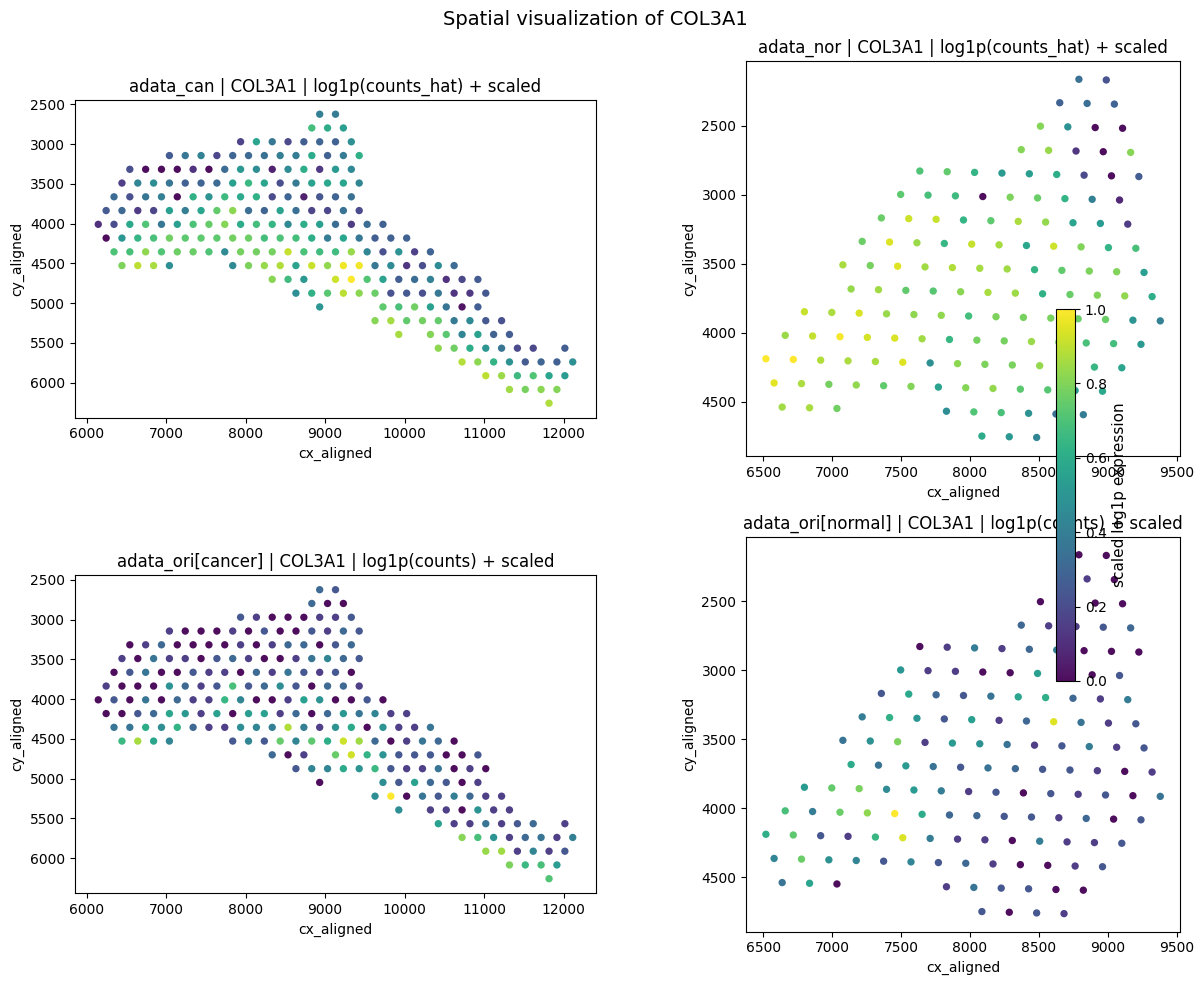

In [14]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt

gene = "COL3A1"
x_col, y_col = "cx_aligned", "cy_aligned"

# ========= 1)  =========
def resolve_gene_name(ad, gene):
    #  var_names 
    if gene in ad.var_names:
        return gene
    
    #  var['gene_ids'] / var['gene_name'] / var['genes'] 
    for col in ["gene_ids", "gene_name", "genes"]:
        if col in ad.var.columns:
            hit = ad.var.index[ad.var[col].astype(str) == gene]
            if len(hit) > 0:
                return hit[0]
    
    raise KeyError(f"{gene} not in AnnData . ad.var_names[:10]  ad.var.columns")

def get_gene_expr_from_layer(ad, gene, layer):
    g = resolve_gene_name(ad, gene)
    vec = ad[:, [g]].layers[layer]
    if sp.issparse(vec):
        vec = vec.toarray()
    vec = np.asarray(vec).reshape(-1)
    return vec

def get_xy(ad, x_col="cx_aligned", y_col="cy_aligned"):
    if x_col not in ad.obs.columns or y_col not in ad.obs.columns:
        raise KeyError(f"adata.obs missing {x_col} / {y_col}")
    x = pd.to_numeric(ad.obs[x_col], errors="coerce").to_numpy()
    y = pd.to_numeric(ad.obs[y_col], errors="coerce").to_numpy()
    return x, y

def minmax_scale(arr, vmin=None, vmax=None):
    arr = np.asarray(arr, dtype=float)
    if vmin is None:
        vmin = np.nanmin(arr)
    if vmax is None:
        vmax = np.nanmax(arr)
    if np.isclose(vmax, vmin):
        return np.zeros_like(arr, dtype=float)
    return (arr - vmin) / (vmax - vmin)

def plot_spatial(ax, x, y, val, title, cmap="viridis", s=28):
    sc = ax.scatter(x, y, c=val, s=s, cmap=cmap, linewidths=0, alpha=0.95)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_aspect("equal")
    ax.invert_yaxis()   # ;
    return sc

# ========= 2) adata_ori  status  cancer / normal =========
if "status" not in adata_ori.obs.columns:
    raise KeyError("adata_ori.obs missing 'status' column")

status_str = adata_ori.obs["status"].astype(str).str.lower().str.strip()

# 
ori_can_mask = status_str.isin(["cancer", "tumor", "malignant"])
ori_nor_mask = status_str.isin(["normal", "healthy"])

# ,important
if ori_can_mask.sum() == 0:
    ori_can_mask = status_str.str.contains("cancer|tumor|malig", regex=True, na=False)
if ori_nor_mask.sum() == 0:
    ori_nor_mask = status_str.str.contains("normal|healthy", regex=True, na=False)

adata_ori_can = adata_ori[ori_can_mask].copy()
adata_ori_nor = adata_ori[ori_nor_mask].copy()

print("adata_can:", adata_can.shape)
print("adata_nor:", adata_nor.shape)
print("adata_ori_can:", adata_ori_can.shape)
print("adata_ori_nor:", adata_ori_nor.shape)

# ========= 3)  log1p =========
expr_can_hat = np.log1p(get_gene_expr_from_layer(adata_can, gene, "counts_hat"))
expr_nor_hat = np.log1p(get_gene_expr_from_layer(adata_nor, gene, "counts_hat"))
expr_ori_can = np.log1p(get_gene_expr_from_layer(adata_ori_can, gene, "counts"))
expr_ori_nor = np.log1p(get_gene_expr_from_layer(adata_ori_nor, gene, "counts"))

# ========= 4)  scale, =========
all_expr = np.concatenate([expr_can_hat, expr_nor_hat, expr_ori_can, expr_ori_nor])
global_min = np.nanmin(all_expr)
global_max = np.nanmax(all_expr)

expr_can_hat_s = minmax_scale(expr_can_hat, global_min, global_max)
expr_nor_hat_s = minmax_scale(expr_nor_hat, global_min, global_max)
expr_ori_can_s = minmax_scale(expr_ori_can, global_min, global_max)
expr_ori_nor_s = minmax_scale(expr_ori_nor, global_min, global_max)

# ========= 5) coordinates =========
x_can, y_can = get_xy(adata_can, x_col, y_col)
x_nor, y_nor = get_xy(adata_nor, x_col, y_col)
x_ori_can, y_ori_can = get_xy(adata_ori_can, x_col, y_col)
x_ori_nor, y_ori_nor = get_xy(adata_ori_nor, x_col, y_col)

# ========= 6)  =========
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sc1 = plot_spatial(axes[0, 0], x_can, y_can, expr_can_hat_s,
                   f"adata_can | {gene} | log1p(counts_hat) + scaled")
sc2 = plot_spatial(axes[0, 1], x_nor, y_nor, expr_nor_hat_s,
                   f"adata_nor | {gene} | log1p(counts_hat) + scaled")
sc3 = plot_spatial(axes[1, 0], x_ori_can, y_ori_can, expr_ori_can_s,
                   f"adata_ori[cancer] | {gene} | log1p(counts) + scaled")
sc4 = plot_spatial(axes[1, 1], x_ori_nor, y_ori_nor, expr_ori_nor_s,
                   f"adata_ori[normal] | {gene} | log1p(counts) + scaled")

#  colorbar
cbar = fig.colorbar(sc4, ax=axes.ravel().tolist(), fraction=0.02, pad=0.02)
cbar.set_label("scaled log1p expression", fontsize=11)

plt.suptitle(f"Spatial visualization of {gene}", fontsize=14, y=0.98)
plt.tight_layout()
plt.show()

In [15]:
def _dense_from_layer_slice(adata, layer: str, gene_names: List[str]) -> np.ndarray:
    if layer not in adata.layers:
        raise KeyError(f"Layer '{layer}' not found in adata.layers")
    if len(gene_names) == 0:
        return np.zeros((adata.n_obs, 0), dtype=np.float32)

    X = adata.layers[layer]
    gene_idx = adata.var_names.get_indexer(gene_names)
    if np.any(gene_idx < 0):
        missing = [g for g, i in zip(gene_names, gene_idx) if i < 0]
        raise KeyError(f"Genes not found in var_names: {missing[:10]} (showing up to 10)")

    if sp.issparse(X):
        Y = X[:, gene_idx].toarray()
    else:
        Y = np.asarray(X)[:, gene_idx]
    return Y.astype(np.float32, copy=False)

In [16]:
Y = _dense_from_layer_slice(adata_ori, "counts", genes_all)
print("mean =", Y.mean())
print("median =", np.median(Y))
print("p90 =", np.percentile(Y, 90))
print("p95 =", np.percentile(Y, 95))
print("p99 =", np.percentile(Y, 99))
print("max =", Y.max())
print("library size per spot mean =", Y.sum(1).mean())

mean = 0.5297837
median = 0.0
p90 = 1.0
p95 = 2.0
p99 = 7.0
max = 6119.0
library size per spot mean = 19390.613
